# MWE: fitting the PDS 70 disk and planets to JWST AMI data

This notebook fits the star, planets and flared disk model of Blakely et al. (2024, arXiv:2404.13032), validated on simulated data in `mwe_pds70_sim.ipynb`, to an AMIGO reduction of the JWST AMI observation of PDS 70 in F480M, the paper's filter. The data product is local and not in the repository; edit `path` to point at your copy. We may well not reproduce the paper: this is a different reduction, and its calibration is suspect. You should come away knowing how to run the fit on real data, and how to see whether the model can explain them.

The first cell builds the paper's power-law model and loads the F480M DISCO modes, then compares how well a bare star and the paper's model fit them.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from drpangloss.amigo import load_oi_data
from drpangloss.fitting import fit
from drpangloss.imaging import beam
from drpangloss.inference import laplace_cov
from drpangloss.likelihood import whitened_residuals
from drpangloss.limits import delta_mag_to_flux
from drpangloss.models import FlaredDiskPowerLaw, PointSource, System
from drpangloss.plotting import plot_model, plot_residual_map


def planet(sep, pa, delta_mag):
    """A point-source planet at separation (mas) and PA (deg, N to E)."""
    th = jnp.radians(pa)
    return PointSource(
        flux=delta_mag_to_flux(delta_mag),
        dra=sep * jnp.sin(th),
        ddec=sep * jnp.cos(th),
    )


# The power-law model of Blakely et al. (2024), Tables 1-2. The aspect
# ratio is their H_100 = 14.7 au converted to z/rho at r0 (r0 = 52 au at
# 113.43 pc), and symmetric = A_s/A_a = exp(-8.2 + 5.14).
paper = System(
    star=PointSource(),
    b=planet(150.5, 131.2, 5.84),
    c=planet(218.4, 270.0, 6.48),
    disk=FlaredDiskPowerLaw(
        n=6.6,
        radius=460.0,
        fwhm=220.0,
        inc=52.3,
        pa=160.4,
        skew=2.7,
        aspect=0.125,
        symmetric=0.05,
        flux=0.05,
        npix=96,
        pixel_scale_mas=20.0,
    ),
)

path = Path.home() / "code/nuHor/data/PDS70/calibrated_visibility.npy"
data = load_oi_data(path, "F480M")
for name, model in [("star alone", System(star=PointSource())),
                    ("paper model", paper)]:
    chi2 = float(jnp.sum(whitened_residuals(model, data) ** 2))
    print(f"{name:>12}: chi2/N = {chi2 / data.vis.size:.1f}")

W1001 15:02:43.995604 10658201 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  star alone: chi2/N = 734.0


 paper model: chi2/N = 735.7


## Fitting the same model

We fit the same fifteen parameters with the same priors as on the simulated data, starting from the paper's solution. As there, the over-resolved flux is left out, since the DISCO modes do not constrain the overall visibility amplitude.

In [2]:
# Priors after Blakely et al. (2024): boxes for the planets, and Gaussian
# priors on the disk's orientation and surface height from earlier work.
priors = {
    "b.dra": dist.Uniform(0.0, 250.0),
    "b.ddec": dist.Uniform(-250.0, 0.0),
    "b.flux": dist.Uniform(0.0, 0.03),
    "c.dra": dist.Uniform(-300.0, -100.0),
    "c.ddec": dist.Uniform(-100.0, 100.0),
    "c.flux": dist.Uniform(0.0, 0.03),
    "disk.flux": dist.Uniform(0.0, 0.3),
    "disk.radius": dist.Uniform(350.0, 650.0),
    "disk.fwhm": dist.Uniform(30.0, 1000.0),
    "disk.inc": dist.Normal(51.7, 1.0),
    "disk.pa": dist.Normal(160.4, 1.0),
    "disk.skew": dist.Uniform(0.0, 10.0),
    "disk.aspect": dist.TruncatedNormal(0.11, 0.04, low=0.0),
    "disk.n": dist.Uniform(0.0, 100.0),
    "disk.symmetric": dist.Uniform(0.0, 1.0),
}
result = fit(paper, priors, data)
info = result.info
print(
    f"{info['method']} converged in {info['steps']} steps, "
    f"chi2/N = {info['chi2_red']:.1f} over {info['ndata'][0]} modes"
)

lbfgs converged in 145 steps, chi2/N = 715.6 over 738 modes


## The fitted parameters

The table compares the fit with the paper's values, with Laplace uncertainties from the likelihood alone. With χ²/N in the hundreds these error bars are far too small to take literally, and parameters pinned at a prior bound (or with no finite error) are not measured at all.

In [3]:
values = jnp.array([result.values[p] for p in priors])
sigma = jnp.sqrt(jnp.diag(laplace_cov(values, list(priors), data, paper)))
print(f"{'parameter':>15} {'paper':>10} {'fit':>10} {'±':>9}")
for p, x, s in zip(priors, values, sigma):
    print(f"{p:>15} {float(paper.get(p)):10.4g} {float(x):10.4g} {float(s):9.2g}")

      parameter      paper        fit         ±
          b.dra      113.2      19.08       1.1
         b.ddec     -99.13     -133.4       1.1
         b.flux   0.004613    0.01479   0.00031
          c.dra     -218.4     -292.6       nan
         c.ddec  2.604e-06        100       nan
         c.flux   0.002559    0.00932   0.00022
      disk.flux       0.05    0.07723   0.00094
    disk.radius        460      639.3      0.68
      disk.fwhm        220         30       nan
       disk.inc       52.3      51.43      0.11
        disk.pa      160.4      159.2     0.026
      disk.skew        2.7         10       0.9
    disk.aspect      0.125     0.0427    0.0043
         disk.n        6.6      8.109      0.23
 disk.symmetric       0.05  6.218e-11       nan


/Users/benpope/code/drpangloss/.claude/worktrees/pds70-disk/src/drpangloss/inference.py:73: RuntimeWarning: The matrix to invert is not positive definite (the point is not a likelihood maximum, or a parameter is unconstrained); the result has negative or infinite variances.
  return regularized_inverse(hess, ridge=ridge)


## The fitted scene

The paper's model and the fit, rendered alike, with the beam in the lower left, and their difference as a residual map (plain signed pixel differences, not z-scores).

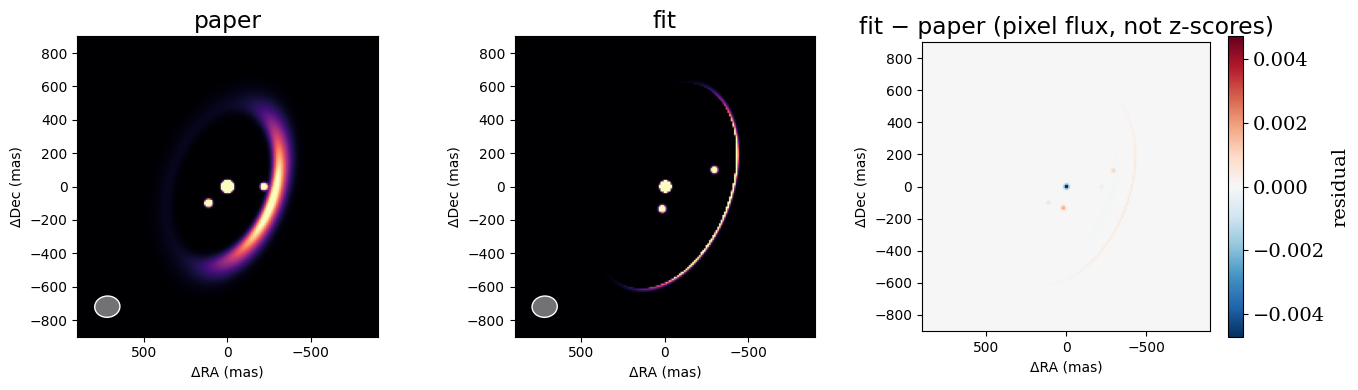

In [4]:
fov, npix = 1800.0, 180
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, model, title in zip(axes, [paper, result.model], ["paper", "fit"]):
    plot_model(
        model, fov, npix, ax=ax, title=title, saturate=0.995,
        beam=beam(data),
    )
residual = result.model.render(npix, fov) - paper.render(npix, fov)
plot_residual_map(
    residual, fov, ax=axes[2],
    title="fit − paper (pixel flux, not z-scores)",
)
plt.tight_layout()
plt.show()

## Where the model fails

The DISCO coefficients of the data against those of the fitted model (left), and the z-scores of the difference against mode number (right), with modes ordered from most to least precise. If the model were adequate the points would follow the diagonal and the z-scores would scatter within ±1. Instead the data coefficients are about ten times larger than any the model produces, and the z-scores have the same spread (rms about 27) in every mode, even though the errors grow fourfold from the first modes to the last. A missed source on the sky would not scale with each mode's error like that; noise whose errors are underestimated by a common factor would.

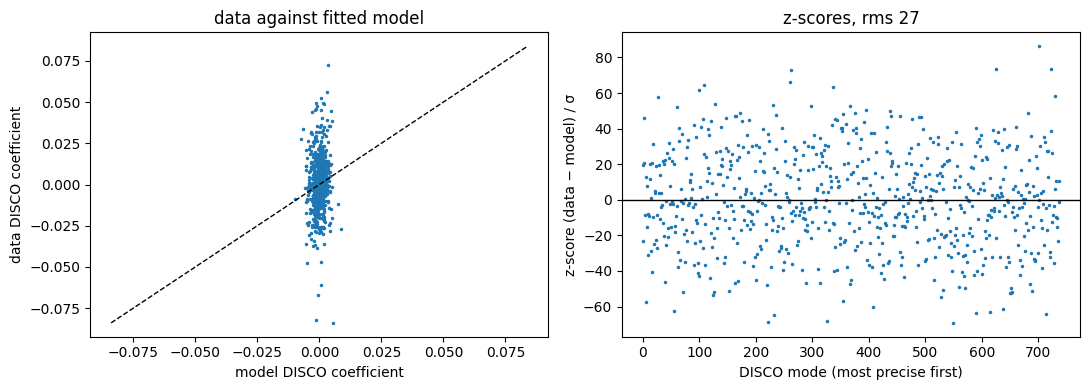

In [5]:
observed, sigma_data = data.flatten_data()
predicted = data.model(result.model)
z = whitened_residuals(result.model, data)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(predicted, observed, ".", ms=3)
lim = float(jnp.abs(observed).max())
axes[0].plot([-lim, lim], [-lim, lim], "k--", lw=1)
axes[0].set(xlabel="model DISCO coefficient", ylabel="data DISCO coefficient",
            title="data against fitted model")
axes[1].plot(z, ".", ms=3)
axes[1].axhline(0.0, color="k", lw=1)
axes[1].set(xlabel="DISCO mode (most precise first)",
            ylabel="z-score (data − model) / σ",
            title=f"z-scores, rms {float(jnp.sqrt(jnp.mean(z ** 2))):.0f}")
plt.tight_layout()
plt.show()

## Summary

The PDS 70 model of Blakely et al. (2024) runs unchanged on this AMIGO product, but neither the paper's solution nor the refitted model comes close to explaining it: the disk and planets reduce χ² only slightly from that of a bare star, and the misfit looks like noise about 27 times larger than the quoted errors, equally in every mode. Since the same model and fit recover every parameter from simulated data of the same kind, this points at the data (most likely the error scaling of this reduction, or its calibration) rather than at the model, and the fitted planet and disk parameters here should not be trusted until that is resolved.